# Chapter 4 Results

This notebook reproduces every quantitative result reported in Chapter 4 of the thesis from the per-query evaluation records in `data/eval_runs`. Each code cell produces one table or one figure, and the section structure follows the chapter. Errored queries count as zero on every effectiveness metric, the development partition holds 357 queries, the held-out test partition holds 356 queries, and MAP@10 is the decision metric throughout.

## Setup

The cells below define the run locations, a record loader, and the plotting style, then assemble the Stage 1 records into two data frames. All numbers downstream derive from these per-query records rather than from precomputed summaries. The vectorless frame covers six methods at three granularities and the vector frame covers three embedding models and three reranking options at the same granularities.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "data" / "eval_runs").exists():
    REPO_ROOT = REPO_ROOT.parent
RUNS = REPO_ROOT / "data" / "eval_runs"

UIBLUE, UIRED, GRAY = "#284887", "#962D30", "#8C8C8C"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

VL_RUNS = {
    "bm25-flat": "stage1_vectorless/run23_20260520_vectorless_dev_357q_bm25_flat",
    "bm25-tree": "stage1_vectorless/run24_20260520_vectorless_dev_357q_bm25_tree",
    "hybrid-flat": "stage1_vectorless/run25_20260524_vectorless_dev_357q_hybrid_flat_deepseek",
    "hybrid-tree": "stage1_vectorless/run26_20260524_vectorless_dev_357q_hybrid_tree_deepseek",
    "llm-tree": "stage1_vectorless/run27_20260525_vectorless_dev_357q_llm_tree_deepseek",
}
LLM_FLAT_RUNS = {
    "ayat": "stage1_vectorless/run28a_20260526_vectorless_dev_357q_llm_flat_ayat_deepseek",
    "pasal": "stage1_vectorless/run28b_20260526_vectorless_dev_357q_llm_flat_pasal_deepseek",
    "rincian": "stage1_vectorless/run28c_20260527_vectorless_dev_357q_llm_flat_rincian_deepseek",
}
VECTOR_RUN = "stage1_vector/run29_20260526_vector_dev_357q_full"
GRANULARITIES = ["pasal", "ayat", "rincian"]
EFFECTIVENESS = [c for c in [
    "map@10", "recall@1", "recall@2", "recall@10", "mrr@10", "hit@1",
    "sibling_hit@1", "doc_pick_hit", "within_doc_hit@1",
] ]

def load_records(rel):
    """Read one records file into a list of dicts, zeroing metrics of errored queries."""
    rows = []
    with open(RUNS / rel, encoding="utf-8") as f:
        for line in f:
            r = json.loads(line)
            if not r.get("worker_ok", True):
                for m in EFFECTIVENESS:
                    if m in r:
                        r[m] = 0.0
            rows.append(r)
    return rows

def frame(rows, **labels):
    keep = EFFECTIVENESS + ["query_id", "query_type", "num_relevant",
                            "total_tokens", "llm_calls", "elapsed_s", "worker_ok"]
    df = pd.DataFrame([{k: r.get(k) for k in keep} for r in rows])
    df = df.drop_duplicates(subset="query_id", keep="last")
    for k, v in labels.items():
        df[k] = v
    return df

print(f"Repository root: {REPO_ROOT.name}")

Repository root: vectorless-and-vector-based-retrieval-for-indonesian-legal-documents


In [2]:
vl_parts = []
for method, run in VL_RUNS.items():
    for gran in GRANULARITIES:
        rows = load_records(f"{run}/records/{method}__{gran}.jsonl")
        vl_parts.append(frame(rows, method=method, granularity=gran))
for gran, run in LLM_FLAT_RUNS.items():
    rows = load_records(f"{run}/records/llm-flat__{gran}.jsonl")
    vl_parts.append(frame(rows, method="llm-flat", granularity=gran))
df_vl = pd.concat(vl_parts, ignore_index=True)
print(f"Vectorless Stage 1 records: {len(df_vl)} rows, "
      f"{df_vl.method.nunique()} methods, {df_vl.granularity.nunique()} granularities")

Vectorless Stage 1 records: 6426 rows, 6 methods, 3 granularities


In [3]:
EMBEDDINGS = ["bge-m3", "multilingual-e5-large-instruct", "all-nusabert-large-v4"]
RERANKERS = ["none", "bge-reranker-v2-m3", "qwen3-reranker-0.6b"]
vec_parts = []
for gran in GRANULARITIES:
    for emb in EMBEDDINGS:
        for rer in RERANKERS:
            rel = f"{VECTOR_RUN}/records/vector-dense__{gran}__{emb}__{rer}.jsonl"
            vec_parts.append(frame(load_records(rel), embedding=emb, reranker=rer, granularity=gran))
df_vec = pd.concat(vec_parts, ignore_index=True)
print(f"Vector Stage 1 records: {len(df_vec)} rows, "
      f"{df_vec.embedding.nunique()} embeddings, {df_vec.reranker.nunique()} rerankers")

Vector Stage 1 records: 9639 rows, 3 embeddings, 3 rerankers


## 4.1 Vectorless Baseline Results

This section reproduces the Stage 1 evaluation of the 18 vectorless configurations on the development partition. The ranking table corresponds to Table 4.1 in the thesis, with hybrid-tree at the pasal granularity on top at 0.8974 MAP@10. The decomposition table and the by-type table reproduce the hierarchical bottleneck analysis and the query-type profile of Section 4.1.

In [4]:
# Table 4.1, all vectorless configurations ranked by MAP@10.
vl_map = (df_vl.groupby(["method", "granularity"])["map@10"].mean()
          .reset_index().sort_values("map@10", ascending=False, ignore_index=True))
vl_map

,method,granularity,map@10
0,hybrid-tree,pasal,0.8974
1,hybrid-flat,pasal,0.8954
2,llm-tree,pasal,0.8868
3,llm-flat,pasal,0.8840
4,llm-flat,rincian,0.8609
5,hybrid-tree,ayat,0.8327
6,llm-flat,ayat,0.8198
7,llm-tree,rincian,0.7761
8,hybrid-flat,ayat,0.7741
9,llm-tree,ayat,0.7698


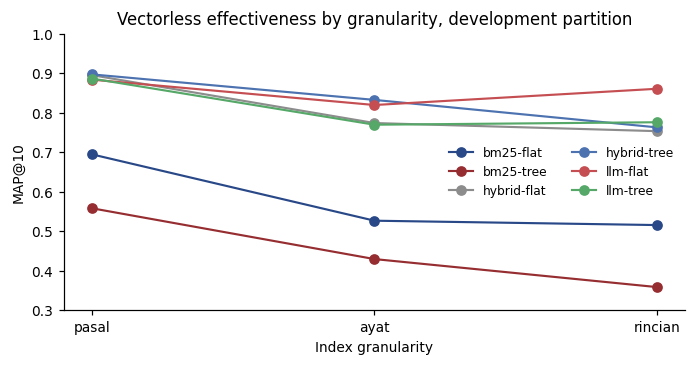

In [5]:
# Figure, effect of index granularity on each vectorless method.
pivot = vl_map.pivot(index="granularity", columns="method", values="map@10").loc[GRANULARITIES]
fig, ax = plt.subplots(figsize=(6.4, 3.4))
for method, color in zip(sorted(pivot.columns), [UIBLUE, UIRED, GRAY, "#4C72B0", "#C44E52", "#55A868"]):
    ax.plot(pivot.index, pivot[method], marker="o", label=method, color=color, linewidth=1.4)
ax.set_xlabel("Index granularity")
ax.set_ylabel("MAP@10")
ax.set_ylim(0.3, 1.0)
ax.legend(frameon=False, ncol=2, fontsize=8)
ax.set_title("Vectorless effectiveness by granularity, development partition")
plt.tight_layout()
plt.show()

In [6]:
# Hierarchical decomposition at pasal, document selection versus within-document ranking.
tree = df_vl[(df_vl.granularity == "pasal") & df_vl.method.str.endswith("tree")]
decomp = tree.groupby("method").apply(lambda g: pd.Series({
    "gold_document_found": g["doc_pick_hit"].mean(),
    "gold_node_first_when_found": g.loc[g["doc_pick_hit"] == 1, "within_doc_hit@1"].mean(),
    "overall_hit@1": g["hit@1"].mean(),
}), include_groups=False)
decomp

,gold_document_found,gold_node_first_when_found,overall_hit@1
method,,,
bm25-tree,0.8964,0.6344,0.5266
hybrid-tree,0.9608,0.9563,0.8880
llm-tree,0.9496,0.9469,0.8880


In [7]:
# Results by query type at pasal, one diagnostic metric per type.
at_pasal = df_vl[df_vl.granularity == "pasal"]
bytype = pd.DataFrame({
    "factual_recall@10": at_pasal[at_pasal.query_type == "factual"].groupby("method")["recall@10"].mean(),
    "paraphrased_recall@10": at_pasal[at_pasal.query_type == "paraphrased"].groupby("method")["recall@10"].mean(),
    "multihop_recall@2": at_pasal[at_pasal.query_type == "multihop"].groupby("method")["recall@2"].mean(),
})
bytype.sort_values("multihop_recall@2", ascending=False)

,factual_recall@10,paraphrased_recall@10,multihop_recall@2
method,,,
hybrid-flat,1.0000,0.7934,0.9204
hybrid-tree,0.9675,0.8595,0.8982
llm-tree,0.9187,0.8926,0.8805
llm-flat,0.9512,0.9008,0.8230
bm25-flat,0.9837,0.7190,0.6416
bm25-tree,0.7642,0.6033,0.5531


## 4.2 Vector Baseline Results

This section reproduces the Stage 1 evaluation of the 27 vector configurations on the development partition. The leading pair is BGE-M3 and Multilingual E5, each with the BGE v2 M3 reranker at the pasal granularity, and the Indonesian-specialized model trails both multilingual models at every granularity. The reranker lift table quantifies how much the cross-encoder adds over the unreranked first stage.

In [8]:
# All 27 vector configurations ranked by MAP@10.
vec_map = (df_vec.groupby(["embedding", "reranker", "granularity"])["map@10"].mean()
           .reset_index().sort_values("map@10", ascending=False, ignore_index=True))
vec_map.head(12)

,embedding,reranker,granularity,map@10
0,bge-m3,bge-reranker-v2-m3,pasal,0.8898
1,multilingual-e5-large-instruct,bge-reranker-v2-m3,pasal,0.8870
2,multilingual-e5-large-instruct,qwen3-reranker-0.6b,pasal,0.8280
3,bge-m3,qwen3-reranker-0.6b,pasal,0.8257
4,all-nusabert-large-v4,bge-reranker-v2-m3,pasal,0.8057
5,bge-m3,none,pasal,0.7948
6,multilingual-e5-large-instruct,none,pasal,0.7788
7,bge-m3,bge-reranker-v2-m3,ayat,0.7726
8,multilingual-e5-large-instruct,bge-reranker-v2-m3,ayat,0.7617
9,all-nusabert-large-v4,qwen3-reranker-0.6b,pasal,0.7515


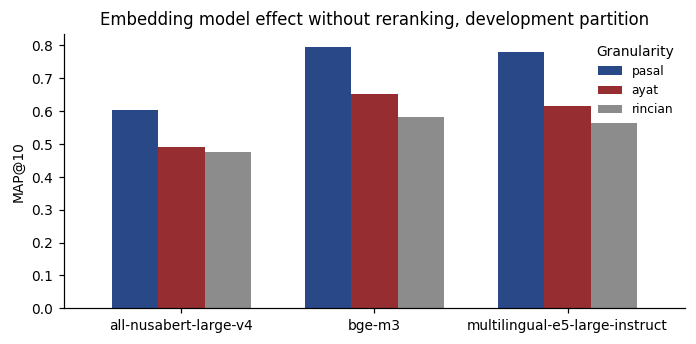

In [9]:
# Figure, embedding model comparison without a reranker.
no_rer = (df_vec[df_vec.reranker == "none"]
          .groupby(["embedding", "granularity"])["map@10"].mean().unstack()[GRANULARITIES])
fig, ax = plt.subplots(figsize=(6.4, 3.2))
no_rer.plot(kind="bar", ax=ax, color=[UIBLUE, UIRED, GRAY], width=0.72)
ax.set_ylabel("MAP@10")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Granularity", frameon=False, fontsize=8)
ax.set_title("Embedding model effect without reranking, development partition")
plt.tight_layout()
plt.show()

In [10]:
# Reranker lift over the unreranked first stage, MAP@10 at pasal.
pasal_vec = df_vec[df_vec.granularity == "pasal"].groupby(["embedding", "reranker"])["map@10"].mean().unstack()
lift = pasal_vec.sub(pasal_vec["none"], axis=0)
pd.concat({"map@10": pasal_vec, "lift_over_none": lift.drop(columns="none")}, axis=1)

map@10                             \
reranker                       bge-reranker-v2-m3   none qwen3-reranker-0.6b   
embedding                                                                      
all-nusabert-large-v4                      0.8057 0.6017              0.7515   
bge-m3                                     0.8898 0.7948              0.8257   
multilingual-e5-large-instruct             0.8870 0.7788              0.8280   

                                   lift_over_none                      
reranker                       bge-reranker-v2-m3 qwen3-reranker-0.6b  
embedding                                                              
all-nusabert-large-v4                      0.2040              0.1498  
bge-m3                                     0.0950              0.0309  
multilingual-e5-large-instruct             0.1082              0.0492

## 4.3 Cross-Paradigm Comparison

This section compares the best configuration from each paradigm at their Stage 1 default settings on the development partition. Vectorless hybrid-tree leads on the ranking metrics while the vector pipeline leads on coverage at depth ten, and per-query cost separates the paradigms far more than effectiveness does. The sibling-hit table reproduces the near-miss diagnostic that grows as the index gets finer.

In [11]:
# Best configuration from each paradigm at default settings.
best_vl = df_vl[(df_vl.method == "hybrid-tree") & (df_vl.granularity == "pasal")]
best_vec = df_vec[(df_vec.embedding == "bge-m3") & (df_vec.reranker == "bge-reranker-v2-m3")
                  & (df_vec.granularity == "pasal")]
metrics = ["map@10", "recall@2", "recall@10", "mrr@10", "hit@1", "total_tokens", "llm_calls", "elapsed_s"]
pd.DataFrame({
    "vectorless_hybrid_tree": best_vl[metrics].mean(),
    "vector_bgem3_v2m3": best_vec[metrics].mean(),
})

,vectorless_hybrid_tree,vector_bgem3_v2m3
map@10,0.8974,0.8898
recall@2,0.9034,0.8768
recall@10,0.9244,0.9776
mrr@10,0.9074,0.9153
hit@1,0.8880,0.8711
total_tokens,138055.1653,0.0000
llm_calls,2.0056,0.0000
elapsed_s,13.8410,1.7014


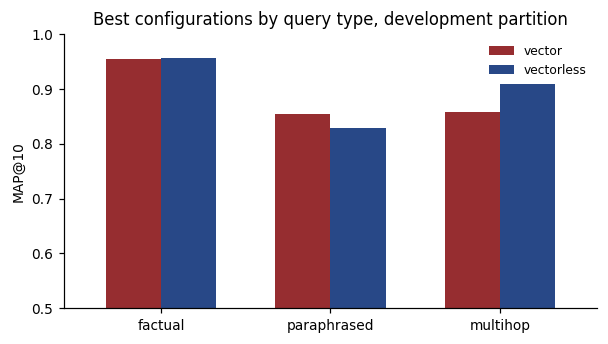

In [12]:
# Figure, best configurations by query type on the development partition.
rows = []
for name, d in [("vectorless", best_vl), ("vector", best_vec)]:
    for qt in ["factual", "paraphrased", "multihop"]:
        rows.append({"paradigm": name, "query_type": qt,
                     "map@10": d[d.query_type == qt]["map@10"].mean()})
bt = pd.DataFrame(rows).pivot(index="query_type", columns="paradigm", values="map@10")
bt = bt.loc[["factual", "paraphrased", "multihop"]]
fig, ax = plt.subplots(figsize=(5.6, 3.2))
bt.plot(kind="bar", ax=ax, color=[UIRED, UIBLUE], width=0.65)
ax.set_ylabel("MAP@10")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.set_ylim(0.5, 1.0)
ax.legend(frameon=False, fontsize=8)
ax.set_title("Best configurations by query type, development partition")
plt.tight_layout()
plt.show()

In [13]:
# Sibling-hit rate at rank one by granularity, near misses that land on a sibling node.
sib_vl = df_vl.groupby("granularity")["sibling_hit@1"].mean().rename("vectorless_mean")
sib_vec = df_vec.groupby("granularity")["sibling_hit@1"].mean().rename("vector_mean")
pd.concat([sib_vl, sib_vec], axis=1).loc[GRANULARITIES]

,vectorless_mean,vector_mean
granularity,,
pasal,0.0028,0.0053
ayat,0.0770,0.1152
rincian,0.0724,0.1164


## 4.4 Optimization Results

This section reproduces the Stage 2 sequential optimization of the best configuration from each paradigm on the development partition. The vectorless side accepted a larger candidate pool, a wider document pick, and the deepseek-v4-pro upgrade, and it rejected query expansion. The vector side accepted a deeper first stage and query expansion, and it rejected the reranker swap.

In [14]:
# Vectorless tuning trajectory, MAP@10 at pasal for each Stage 2 step.
def run_map10(rel_dir, pattern="*.jsonl"):
    """Mean MAP@10 over the run, keeping the last record per query as retries overwrite."""
    per_query = {}
    for path in sorted((RUNS / rel_dir / "records").glob(pattern)):
        for r in load_records(f"{rel_dir}/records/{path.name}"):
            per_query[r["query_id"]] = r.get("map@10") or 0.0
    return sum(per_query.values()) / len(per_query)

vl_steps = {
    "stage 1 baseline": (f"{VL_RUNS['hybrid-tree']}", "*__pasal.jsonl"),
    "candidates 10": "stage2_vectorless/run50_bm25topk10",
    "candidates 20": "stage2_vectorless/run50_bm25topk20",
    "candidates 30": "stage2_vectorless/run50_bm25topk30",
    "candidates 50": "stage2_vectorless/run50_bm25topk50",
    "document pick 1": "stage2_vectorless/run51_docpick1",
    "document pick 2": "stage2_vectorless/run51_docpick2",
    "document pick 3": "stage2_vectorless/run51_docpick3",
    "document pick 5": "stage2_vectorless/run51_docpick5",
    "deepseek-v4-pro": "stage2_vectorless/run52_v4pro_topk20_docpick5",
    "query expansion": "stage2_vectorless/run53_qe_topk20_docpick5",
}
pd.Series({k: run_map10(*v) if isinstance(v, tuple) else run_map10(v)
           for k, v in vl_steps.items()}, name="map@10").to_frame()

,map@10
stage 1 baseline,0.8974
candidates 10,0.9077
candidates 20,0.9434
candidates 30,0.9396
candidates 50,0.9395
document pick 1,0.8949
document pick 2,0.9345
document pick 3,0.9326
document pick 5,0.9445
deepseek-v4-pro,0.9516


In [15]:
# Vector tuning trajectory, MAP@10 at pasal for each Stage 2 step.
vec_steps = {
    "first stage 20": "stage2_vector/run38_topn20",
    "first stage 50": "stage2_vector/run38_topn50",
    "first stage 100": "stage2_vector/run38_topn100",
    "first stage 200": "stage2_vector/run38_topn200",
    "ef 64": "stage2_vector/run39_ef64_topn100",
    "ef 128": "stage2_vector/run39_ef128_topn100",
    "ef 256": "stage2_vector/run39_ef256_topn100",
    "ef 512": "stage2_vector/run39_ef512_topn100",
    "reranker v2 gemma": "stage2_vector/run41_v2gemma_topn100_ef64",
    "query expansion": "stage2_vector/run42_qe_v2m3_topn100_ef64",
}
pd.Series({k: run_map10(v) for k, v in vec_steps.items()}, name="map@10").to_frame()

,map@10
first stage 20,0.8801
first stage 50,0.8898
first stage 100,0.8933
first stage 200,0.8920
ef 64,0.8933
ef 128,0.8933
ef 256,0.8933
ef 512,0.8933
reranker v2 gemma,0.8661
query expansion,0.8974


## 4.5 Final Evaluation on the Test Partition

This section reproduces the Stage 3 evaluation of the two tuned configurations on the held-out test partition of 356 queries. The significance table reproduces Table 4.8 with the paired randomization test of Section 3.6.3, and the contrast cell reproduces the multihop analysis, including the failure breakdown that separates ordering failures from retrieval failures. The vectorless advantage holds on every ranking metric while coverage at depth ten is statistically tied.

In [16]:
# Tuned configurations on the test partition, Table 4.7.
import sys
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from scripts.eval.multihop_contrast import load_run_records, metric_value, failure_breakdown

rec_vl = load_run_records(RUNS / "stage3_test/rq4_test_hybrid_tree")
rec_vec = load_run_records(RUNS / "stage3_test/rq4_test_v2m3_qe")
qids = sorted(set(rec_vl) & set(rec_vec))
TEST_METRICS = ["map@10", "recall@2", "recall@10", "mrr@10", "hit@1"]
pd.DataFrame({
    "vectorless_tuned": {m: sum(metric_value(rec_vl[q], m) for q in qids) / len(qids) for m in TEST_METRICS},
    "vector_tuned": {m: sum(metric_value(rec_vec[q], m) for q in qids) / len(qids) for m in TEST_METRICS},
})

,vectorless_tuned,vector_tuned
map@10,0.9489,0.8750
recall@2,0.9466,0.8834
recall@10,0.9888,0.9789
mrr@10,0.9552,0.9047
hit@1,0.9326,0.8455


In [17]:
# Paired significance tests on the test partition, Table 4.8.
from scripts.eval.core.significance import compare_paired

subset = [q for q in qids if rec_vl[q].get("query_type") == "multihop"
          and rec_vl[q].get("num_relevant") == 2]
rows = []
for metric in TEST_METRICS:
    a = [metric_value(rec_vl[q], metric) for q in qids]
    b = [metric_value(rec_vec[q], metric) for q in qids]
    res = compare_paired(a, b)
    rows.append({"metric": metric, "n": len(qids),
                 "difference": sum(a) / len(a) - sum(b) / len(b),
                 "p_value": res["paired_randomization"]["p_value"],
                 "cohens_d": res["cohens_d"]["d"]})
a = [metric_value(rec_vl[q], "recall@2") for q in subset]
b = [metric_value(rec_vec[q], "recall@2") for q in subset]
res = compare_paired(a, b)
rows.append({"metric": "recall@2, multihop", "n": len(subset),
             "difference": sum(a) / len(a) - sum(b) / len(b),
             "p_value": res["paired_randomization"]["p_value"],
             "cohens_d": res["cohens_d"]["d"]})
pd.DataFrame(rows).set_index("metric")

,n,difference,p_value,cohens_d
metric,,,,
map@10,356,0.0738,0.0001,0.2684
recall@2,356,0.0632,0.0001,0.2145
recall@10,356,0.0098,0.2881,0.0667
mrr@10,356,0.0505,0.0008,0.1851
hit@1,356,0.0871,0.0002,0.2046
"recall@2, multihop",78,0.1603,0.0001,0.5626


In [18]:
# Multihop contrast and failure breakdown, the analysis behind the last paragraph of Section 4.5.
import subprocess
out = subprocess.run([sys.executable, str(REPO_ROOT / "scripts/eval/multihop_contrast.py")],
                     capture_output=True, text=True, cwd=REPO_ROOT)
print(out.stdout.strip())

Shared queries: 356
Two-anchor multihop subset: 78, complement: 278
recall@2 margin (a minus b): subset 0.1603, complement 0.0360, overall 0.0632
Observed contrast (subset minus complement): 0.1243
Permutation test (10000 permutations, seed 42): p two-sided 0.0008, one-sided 0.0008
Bootstrap 95 percent CI of the contrast (1000 resamples): [0.0522, 0.1984]
Side a subset failures (recall@2 below 1.0): 16 (all anchors retrieved 16, one missing 0, all missing 0)
Side b subset failures (recall@2 below 1.0): 42 (all anchors retrieved 34, one missing 8, all missing 0)


## 4.6 Cost-Effectiveness Analysis

This section reproduces the cost figures that accompany the effectiveness results. Per-query cost at default settings separates the configurations into three groups, the tuned configurations differ by about 150 times in tokens and 16 times in latency, and the shared indexing pipeline is a one-time cost dominated by summary annotation. Latencies are indicative because the GPU-bound stages ran on rented hardware.

In [19]:
# Per-query cost at default settings on the development partition, pasal granularity.
cost_vl = (df_vl[df_vl.granularity == "pasal"].groupby("method")
           .agg(map10=("map@10", "mean"), tokens=("total_tokens", "mean"),
                llm_calls=("llm_calls", "mean"), latency_s=("elapsed_s", "mean")))
best_cells = df_vec[(df_vec.granularity == "pasal") & (df_vec.reranker != "qwen3-reranker-0.6b")]
cost_vec = (best_cells.groupby(["embedding", "reranker"])
            .agg(map10=("map@10", "mean"), tokens=("total_tokens", "mean"),
                 llm_calls=("llm_calls", "mean"), latency_s=("elapsed_s", "mean")))
cost_vec.index = [f"{e} + {r}" for e, r in cost_vec.index]
pd.concat([cost_vl, cost_vec]).sort_values("map10", ascending=False).fillna(0)

,map10,tokens,llm_calls,latency_s
hybrid-tree,0.8974,138055.1653,2.0056,13.8410
hybrid-flat,0.8954,10683.8375,1.0028,6.7063
bge-m3 + bge-reranker-v2-m3,0.8898,0.0000,0.0000,1.7014
multilingual-e5-large-instruct + bge-reranker-v2-m3,0.8870,0.0000,0.0000,1.3478
llm-tree,0.8868,143741.3473,4.1877,11.0918
llm-flat,0.8840,877530.1877,1.9888,13.1349
all-nusabert-large-v4 + bge-reranker-v2-m3,0.8057,0.0000,0.0000,1.0154
bge-m3 + none,0.7948,0.0000,0.0000,0.1189
multilingual-e5-large-instruct + none,0.7788,0.0000,0.0000,0.1116
bm25-flat,0.6948,0.0000,0.0000,0.4873


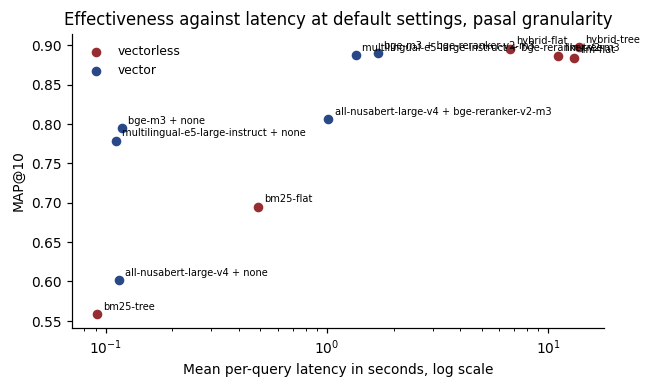

In [20]:
# Figure, effectiveness against per-query latency at default settings.
combined = pd.concat([cost_vl.assign(paradigm="vectorless"), cost_vec.assign(paradigm="vector")])
fig, ax = plt.subplots(figsize=(6.0, 3.6))
for paradigm, color in [("vectorless", UIRED), ("vector", UIBLUE)]:
    part = combined[combined.paradigm == paradigm]
    ax.scatter(part.latency_s, part.map10, color=color, label=paradigm, s=28)
    for name, row in part.iterrows():
        ax.annotate(name, (row.latency_s, row.map10), fontsize=6.5,
                    xytext=(4, 3), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("Mean per-query latency in seconds, log scale")
ax.set_ylabel("MAP@10")
ax.legend(frameon=False, fontsize=8)
ax.set_title("Effectiveness against latency at default settings, pasal granularity")
plt.tight_layout()
plt.show()

In [21]:
# Per-query cost of the tuned configurations on the test partition.
def cost_summary(records):
    df = pd.DataFrame([{k: r.get(k, 0) or 0 for k in
                        ["llm_calls", "input_tokens", "output_tokens", "total_tokens", "elapsed_s"]}
                       for r in records.values()])
    out = df.mean().rename("mean").to_frame()
    out.loc["elapsed_s", "p95"] = df["elapsed_s"].quantile(0.95)
    return out

pd.concat({"vectorless_tuned": cost_summary(rec_vl), "vector_tuned": cost_summary(rec_vec)}, axis=1)

vectorless_tuned         vector_tuned       
                          mean     p95         mean    p95
llm_calls               2.0056     NaN       0.0000    NaN
input_tokens       160842.8371     NaN       0.0000    NaN
output_tokens        2487.8511     NaN       0.0000    NaN
total_tokens       163330.6882     NaN       0.0000    NaN
elapsed_s              42.4313 66.9900       2.6863 5.1225

In [22]:
# One-time indexing cost in tokens, shared by both paradigms.
with open(REPO_ROOT / "data" / "indexing_cost_summary.json", encoding="utf-8") as f:
    ic = json.load(f)
table = pd.DataFrame({g: {s: ic[g]["per_stage"][s]["tokens"] for s in ic[g]["per_stage"]}
                      for g in GRANULARITIES}).T
table["granularity_total"] = table.sum(axis=1)
total = table.loc["pasal", ["parse", "ocr_clean"]].sum() + table["summary"].sum()
print(f"Parse {table.loc['pasal', 'parse'] / 1e6:.1f}M, "
      f"text repair {table.loc['pasal', 'ocr_clean'] / 1e6:.1f}M, "
      f"summary across granularities {table['summary'].sum() / 1e6:.1f}M, "
      f"total {total / 1e6:.1f}M tokens")
table

Parse 16.3M, text repair 10.7M, summary across granularities 50.0M, total 77.0M tokens


,parse,ocr_clean,summary,resplit,granularity_total
pasal,16338374.0000,10650421.0000,7644211.0000,NaN,34633006.0000
ayat,NaN,NaN,15376566.0000,0.0000,15376566.0000
rincian,NaN,NaN,27026219.0000,0.0000,27026219.0000
